# 01 - EDA: is_like prediction

This notebook provides a compact exploratory data analysis focused on the `is_like` label.
It assumes processed artifacts exist in `data/processed/` (see README for preprocessing steps).

In [3]:
# Imports and display settings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns
sns.set_theme(style='whitegrid')
%matplotlib inline

In [4]:
# Load processed artifacts (X, y, meta) generated by preprocessing
proc = Path('../data/processed')
# show files we expect
print('Processed files:', [p.name for p in proc.glob('*')])
X = pd.read_csv(proc / 'X.csv')
y = pd.read_csv(proc / 'y.csv')
meta = pd.read_csv(proc / 'meta.csv') if (proc / 'meta.csv').exists() else pd.DataFrame()
# training columns and banned columns (if available)
if (proc / 'features_summary.json').exists():
    print((proc / 'features_summary.json').read_text())
print('Loaded shapes:', X.shape, y.shape, meta.shape)

Processed files: ['banned_columns_removed.txt', 'cols_categorical.txt', 'cols_ids.txt', 'cols_numeric.txt', 'cols_target.txt', 'dataset_joined.csv', 'features_summary.json', 'meta.csv', 'preprocess_summary.json', 'test_idx.csv', 'training_columns.txt', 'train_idx.csv', 'val_idx.csv', 'X.csv', 'y.csv']
{
  "training_columns": [
    "date",
    "hourmin",
    "time_ms",
    "is_rand",
    "tab",
    "c0",
    "c1",
    "cluster",
    "c1_videos",
    "c2",
    "cluster_videos"
  ],
  "banned_columns_removed": [
    "is_click",
    "is_follow",
    "is_comment",
    "is_forward",
    "is_hate",
    "long_view",
    "play_time_ms",
    "duration_ms",
    "profile_stay_time",
    "comment_stay_time",
    "is_profile_enter"
  ],
  "col_types": {
    "ids": [
      "user_id",
      "video_id"
    ],
    "numeric": [
      "date",
      "hourmin",
      "time_ms",
      "is_rand",
      "tab",
      "c0",
      "c1",
      "cluster",
      "c1_videos",
      "c2",
      "cluster_videos"
    ],

## Label prevalence
Check the distribution of the `is_like` label — important for class imbalance handling.

In [5]:
y_col = y.columns[0] if y.shape[1] == 1 else 'is_like'
label_counts = y[y_col].value_counts(dropna=False)
print(label_counts)
frac = label_counts / len(y)
print('\nLabel fractions:\n', frac)

is_like
0    42789
1      239
Name: count, dtype: int64

Label fractions:
 is_like
0    0.994445
1    0.005555
Name: count, dtype: float64


## Missingness overview
Quick scan of missing values by column (fraction missing).

In [6]:
miss = X.isna().mean().sort_values(ascending=False)
display(miss.head(30))

date              0.0
hourmin           0.0
is_rand           0.0
tab               0.0
c0                0.0
c1                0.0
cluster           0.0
c1_videos         0.0
c2                0.0
cluster_videos    0.0
dtype: float64

## User feature distributions
Plot a few numeric user-level features (if present).

In [7]:
user_feats = [c for c in X.columns if 'user' in c.lower() and X[c].dtype.kind in 'fi'][:6]
print('User numeric features found:', user_feats)
if user_feats:
    fig, axs = plt.subplots(len(user_feats), 1, figsize=(6, 3*len(user_feats)))
    for i, c in enumerate(user_feats):
        ax = axs[i] if len(user_feats) > 1 else axs
        X[c].dropna().hist(bins=30, ax=ax)
        ax.set_title(c)
    plt.tight_layout()
else:
    print('No user numeric features found')

User numeric features found: []
No user numeric features found


## Video feature distributions
Plot a few numeric video-level features (if present).

Video numeric features found: ['c1_videos', 'cluster_videos']


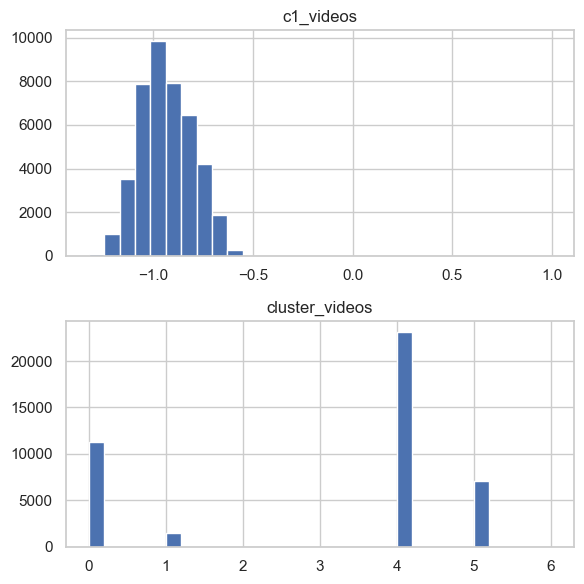

In [8]:
video_feats = [c for c in X.columns if 'video' in c.lower() and X[c].dtype.kind in 'fi'][:6]
print('Video numeric features found:', video_feats)
if video_feats:
    fig, axs = plt.subplots(len(video_feats), 1, figsize=(6, 3*len(video_feats)))
    for i, c in enumerate(video_feats):
        ax = axs[i] if len(video_feats) > 1 else axs
        X[c].dropna().hist(bins=30, ax=ax)
        ax.set_title(c)
    plt.tight_layout()
else:
    print('No video numeric features found')

## Correlation checks for allowed numeric features
Compute pairwise Pearson correlations for numeric columns and inspect strong correlations.

In [9]:
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
corr = X[num_cols].corr().abs() if num_cols else pd.DataFrame()
if not corr.empty:
    pairs = (corr.where(~np.eye(corr.shape[0],dtype=bool)).stack().sort_values(ascending=False))
    display(pairs.head(20))
else:
    print('No numeric columns found for correlation analysis')

c1_videos       cluster_videos    0.764403
cluster_videos  c1_videos         0.764403
cluster         c0                0.449372
c0              cluster           0.449372
cluster_videos  c2                0.390838
c2              cluster_videos    0.390838
c1              cluster           0.185890
cluster         c1                0.185890
c1_videos       c2                0.152051
c2              c1_videos         0.152051
tab             c1                0.086120
c1              tab               0.086120
c0              c1                0.082102
c1              c0                0.082102
tab             date              0.055526
date            tab               0.055526
                hourmin           0.052319
hourmin         date              0.052319
tab             cluster           0.050977
cluster         tab               0.050977
dtype: float64

## Leakage columns warning
Carefully inspect columns that may contain post-exposure signals. The preprocessing pipeline enforces a policy, but manual review is recommended. Typical leak candidates: 'click', 'watch_time', 'impression', 'future_*', 'label_*'.

In [10]:
# Quick check for banned keywords in columns
banned_keywords = ['click','watch','impression','future','label','outcome']
leaks = [c for c in X.columns if any(k in c.lower() for k in banned_keywords)]
print('Potential leakage columns detected:', leaks)
leaks[:20]

Potential leakage columns detected: []


[]